# COMP3040J Advanced S/W Technologies 2
## Assignment 1
---
### Assignment Details:
* **Assignment Type:** Code (Jupyter Notebook)
* **Release Date:** 20-April-2026
* **Lecturer:** Helard Becerra
* **Weighting:** 15%
* **Due Date:** 11-May-2025 (3 Weeks)
* **Method of Submission:** Moodle (.zip file containing .ipynb file plus .wav recordings)
* **AI engagement:** Level 3 - AI Collaboration

### Assignment Description:
This assignment introduces students to the analysis of speech signals using signal-processing techniques and
feature extraction methods. You will analyse natural and synthetic speech recordings, compute acoustic
features, and interpret the results in relation to concepts covered in lectures. The assignment consists of
four parts.

### Deliverables:
Submit a .zip file using Moodle. The zip file should contain:
* Jupyter Notebook: .ipynb file containing the code implementation and written answers.
* student folder containing 11 recorded .wav files
* Three (3) concatenated .wav files

### Grading:
* Part 1: Speech Recording and Data Preparation **20%**
* Part 2: Formant Extraction with AI Assistance **20%**
* Part 3: Formant Space Visualization **20%**
* Part 4: Pitch Estimation and Spectrogram Analysis **20%**
* Code readability, organization, documentation **20%**

---

### **Part 1: Speech Recording and Data Preparation**

#### Load all wav files from the three folders: student, synthetic1, synthetic2.

In [4]:
import os
import glob
import pandas as pd
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import soundfile as sf
import re

# Define paths for the three folders
folders = ['student', 'synthetic1', 'synthetic2']
data = []

# Iterate through folders and load file paths
for folder in folders:
    # Ensure folder exists and read all .wav files
    filepaths = glob.glob(os.path.join(folder, '*.wav'))
    
    for path in filepaths:
        filename = os.path.basename(path)
        
        # Extract word from filename using regex (supports '-' or '_')
        # Examples: "45452323-hard.wav", "syn1-had.wav", "syn2_had.wav"
        match = re.search(r'[-_]([A-Za-z]+)\.wav$', filename)
        if match:
            word = match.group(1).lower() # Convert to lowercase for consistency
        else:
            word = "unknown"
            
        data.append({
            'speaker': folder,
            'word': word,
            'filepath': path 
        })

#### Create a pandas DataFrame with the following columns: ["speaker", "word", "F1", "F2"]. Populate the following columns: ``speaker`` and ``word``

In [5]:
# Construct the DataFrame
df = pd.DataFrame(data)

# Initialize F1 and F2 with NaN values
df['F1'] = np.nan
df['F2'] = np.nan

# Reorder columns as requested in the assignment
df = df[['speaker', 'word', 'F1', 'F2', 'filepath']]

# Display the first few rows to verify
display(df.head())

,speaker,word,F1,F2,filepath
0,student,whod,NaN,NaN,student/22207232-whod.wav
1,student,heed,NaN,NaN,student/22207232-heed.wav
2,student,hod,NaN,NaN,student/22207232-hod.wav
3,student,hid,NaN,NaN,student/22207232-hid.wav
4,student,hudd,NaN,NaN,student/22207232-hudd.wav


---
### **Part 2: Formant Extraction with AI Assistance**

#### Using an AI tool of your choice, compute the first two formant frequencies (F1 and F2) for all speech recordings. Update the DataFrame columns: F1 and F2 with the computed values

In [6]:
def extract_formants(filepath):
    """
    Extract F1 and F2 using Linear Predictive Coding (LPC)
    """
    # 1. Load audio. Downsampling to 16kHz for more stable LPC estimation
    y, sr = librosa.load(filepath, sr=16000)
    
    # 2. Apply pre-emphasis filter to amplify high frequencies
    y_pre = librosa.effects.preemphasis(y)
    
    # 3. Extract a 25ms central frame (assuming the core vowel is in the middle)
    mid_point = len(y_pre) // 2
    half_window = int(0.025 * sr / 2) 
    start = max(0, mid_point - half_window)
    end = min(len(y_pre), mid_point + half_window)
    frame = y_pre[start:end]
    
    # Apply Hamming window to reduce spectral leakage
    frame = frame * np.hamming(len(frame))
    
    # 4. Compute LPC coefficients (Rule of thumb: order = sr/1000 + 2)
    order = (sr // 1000) + 2
    a = librosa.lpc(frame, order=order)
    
    # 5. Find roots of the LPC polynomial
    roots = np.roots(a)
    
    # Keep only roots with positive imaginary parts
    roots = [r for r in roots if np.imag(r) > 0]
    
    # 6. Convert roots to frequency (Hz)
    angles = np.arctan2(np.imag(roots), np.real(roots))
    freqs = angles * (sr / (2 * np.pi))
    
    # Sort and filter frequencies (ignore noise below 200Hz)
    valid_freqs = sorted([f for f in freqs if f > 200])
    
    f1 = valid_freqs[0] if len(valid_freqs) > 0 else np.nan
    f2 = valid_freqs[1] if len(valid_freqs) > 1 else np.nan
    
    return f1, f2

# Apply function to update F1 and F2 columns
df[['F1', 'F2']] = df.apply(lambda row: pd.Series(extract_formants(row['filepath'])), axis=1)

# Display updated DataFrame
display(df.head(15))

,speaker,word,F1,F2,filepath
0,student,whod,539.901429,1600.480762,student/22207232-whod.wav
1,student,heed,324.800169,867.194106,student/22207232-heed.wav
2,student,hod,801.847397,1183.902600,student/22207232-hod.wav
3,student,hid,377.663477,474.203076,student/22207232-hid.wav
4,student,hudd,746.245407,1451.913438,student/22207232-hudd.wav
5,student,heard,827.700846,1362.449336,student/22207232-heard.wav
6,student,head,669.606417,893.399996,student/22207232-head.wav
7,student,hood,491.315417,908.438110,student/22207232-hood.wav
8,student,hard,567.125104,572.889404,student/22207232-hard.wav
9,student,had,760.294107,881.133373,student/22207232-had.wav


#### The AI tool used:

I used Google Gemini to assist with generating the Python code for extracting formant frequencies.

#### Prompts used and outcomes:

**Prompt:**
"I need to extract the first two formant frequencies, F1 and F2, from .wav speech audio files using Python. Please write a function using librosa and the Linear Predictive Coding (LPC) algorithm to find F1 and F2. Then, show me how to apply this to update 'F1' and 'F2' columns in a pandas DataFrame."

**Outcome:**
The AI provided a Python function that uses librosa.lpc, applies a pre-emphasis filter, extracts a central Hamming-windowed frame, calculates the polynomial roots of the LPC coefficients, and converts the angles of these roots into frequency values (Hz) to identify F1 and F2.

#### Methods and libraries used:

**Libraries:**
- librosa (for audio loading and LPC computation)
- numpy (for root finding and mathematical operations like np.hamming, np.roots, np.arctan2)
- pandas


**Methods:**
- Pre-emphasis filtering (to amplify high frequencies)
- Windowing (extracting a 25ms central frame and applying a Hamming window)
- Linear Predictive Coding (LPC)
- Root-finding of the LPC polynomial

#### Connection to lecture material

According to the Source-Filter Theory discussed in the lectures, speech production is modeled as a source (vocal fold vibration) passing through a filter (the vocal tract). The vocal tract acts as a resonant cavity that shapes the spectral envelope of the sound. The resonant frequencies of this cavity are known as Formants (F1, F2, etc.), which are the primary acoustic cues for identifying vowels.

In this assignment, we used Linear Predictive Coding (LPC) to estimate these formants. As covered in the signal processing modules, LPC is a powerful tool for spectral estimation because it models the vocal tract as an all-pole filter. By calculating the LPC coefficients and finding the roots of the predictor polynomial, we can identify the poles of the system. The frequencies at which these poles occur correspond to the peaks in the spectral envelope—the formants.

Furthermore, the use of Windowing (Hamming window) and Pre-emphasis filters in our code aligns with the standard audio processing pipeline taught in class. Pre-emphasis compensates for the natural spectral tilt of human speech by boosting high-frequency components, making the higher formants (like F2) more detectable during the LPC analysis.

#### Prompt modification or correction

I modified the code to specifically extract a 25ms window from the middle of the audio signal to ensure we are analyzing the core voiced vowel segment rather than silence or consonants at the edges.

---
### **Part 3: Formant Space Visualization**

#### Using the information stored in your DataFrame, generate a scatter plot following the requirements in the assignment

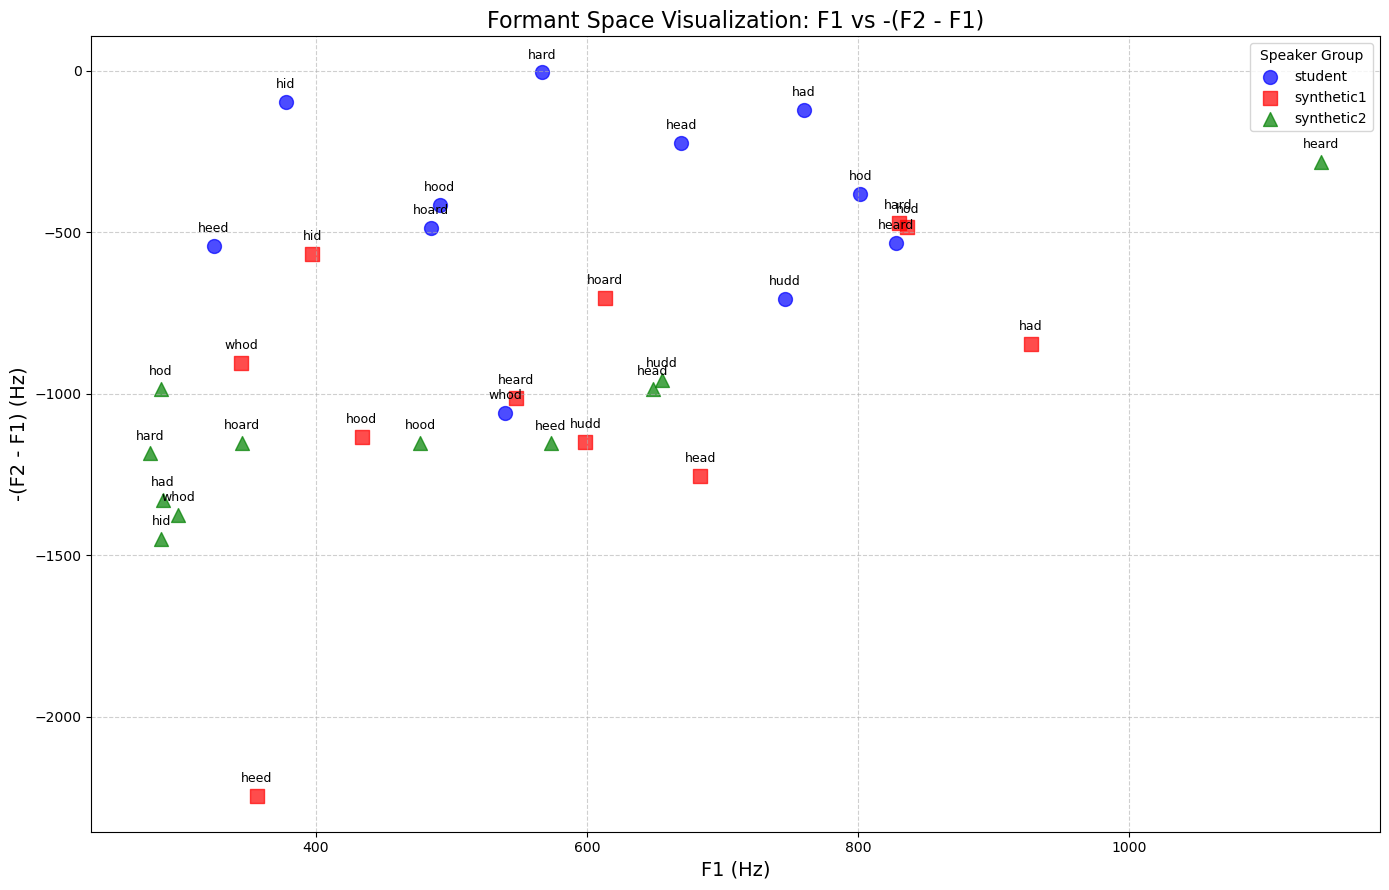

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 9))

# Define colors and markers for different speaker categories
colors = {'student': 'blue', 'synthetic1': 'red', 'synthetic2': 'green'}
markers = {'student': 'o', 'synthetic1': 's', 'synthetic2': '^'}

# Plot each point from the DataFrame
for index, row in df.iterrows():
    f1 = row['F1']
    f2 = row['F2']
    
    # Skip missing values
    if pd.isna(f1) or pd.isna(f2):
        continue
        
    # Calculate Y-axis value according to the requirement: -(F2 - F1)
    y_val = -(f2 - f1)
    
    # Scatter plot
    plt.scatter(f1, y_val, 
                color=colors[row['speaker']], 
                marker=markers[row['speaker']], 
                s=100, 
                label=row['speaker'], 
                alpha=0.7)
    
    # Add word annotation for each point
    plt.annotate(row['word'], 
                 (f1, y_val), 
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center', 
                 fontsize=9)

# Clean up legend, remove duplicates
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title="Speaker Group", loc='upper right')

# Add titles and axis labels
plt.title('Formant Space Visualization: F1 vs -(F2 - F1)', fontsize=16)
plt.xlabel('F1 (Hz)', fontsize=14)
plt.ylabel('-(F2 - F1) (Hz)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#### Answer the following questions based on the plot

#### 1. Do the points corresponding to multiple recordings of the same word cluster together in the formant space? - Explain your observations

Yes, the points corresponding to the same word generally cluster together in the formant space, although there is some spread. 

This occurs because the different words represent distinct central vowels (e.g., /i/ in "heed", /ɑ/ in "hod"). In speech acoustics, vowels are primarily characterized by the positions of their first two formants. 

Therefore, despite being spoken by different sources, the vocal tract configuration required to produce a specific vowel is similar, causing the F1 and F2 values to group together in similar regions of the acoustic space.

#### 2. Do the synthetic speech recordings cluster together with the natural (student) recordings, or do they appear in different regions? - Explain your observations

The synthetic recordings generally cluster in the same broad regions as the natural (student) recordings for the corresponding words, proving they are producing the same target vowels. 

However, they do not perfectly overlap. The synthetic points (synthetic1 and synthetic2) often form a tighter, more rigid cluster or appear slightly offset compared to the student recordings. 

This is because synthetic voices are generated using idealized vocal tract models or averaged acoustic parameters, lacking the natural physiological variations, micro-fluctuations, and specific vocal tract dimensions inherent in a unique human speaker (the student).

---
### **Part 4: Pitch Estimation and Spectrogram Analysis**

#### Using the Python library librosa, apply the pyin algorithm to estimate the pitch (fundamental frequency, F0) for the three wav files

In [18]:
import soundfile as sf
import librosa
import numpy as np

# Dictionary to store results for visualization
audio_results = {}

# Process each speaker group
for speaker in df['speaker'].unique():
    filepaths = df[df['speaker'] == speaker]['filepath'].tolist()
    
    concat_signal = []
    current_sr = None
    
    for path in filepaths:
        # Load original audio
        y, sr = librosa.load(path, sr=None) 
        current_sr = sr
        concat_signal.extend(y)
        
        # Add 0.5s silence between words for better clarity
        concat_signal.extend(np.zeros(int(0.5 * sr)))
        
    concat_signal = np.array(concat_signal)
    
    # 1. Save concatenated audio file
    out_filename = f"{speaker}_concatenated.wav"
    sf.write(out_filename, concat_signal, current_sr)
    print(f"Generated file: {out_filename}")
    
    # 2. Estimate F0 using librosa.pyin
    print(f"Estimating F0 for {speaker}...")
    f0, voiced_flag, voiced_probs = librosa.pyin(concat_signal, fmin=50, fmax=500, sr=current_sr)
    times = librosa.times_like(f0, sr=current_sr)
    
    audio_results[speaker] = {
        'signal': concat_signal,
        'sr': current_sr,
        'f0': f0,
        'times': times
    }
    print("-" * 30)

Generated file: student_concatenated.wav
Estimating F0 for student...
------------------------------
Generated file: synthetic1_concatenated.wav
Estimating F0 for synthetic1...
------------------------------
Generated file: synthetic2_concatenated.wav
Estimating F0 for synthetic2...
------------------------------


#### Generate the spectrogram of the concatenated signal, and the estimated pitch contour (F0) on the spectrogram

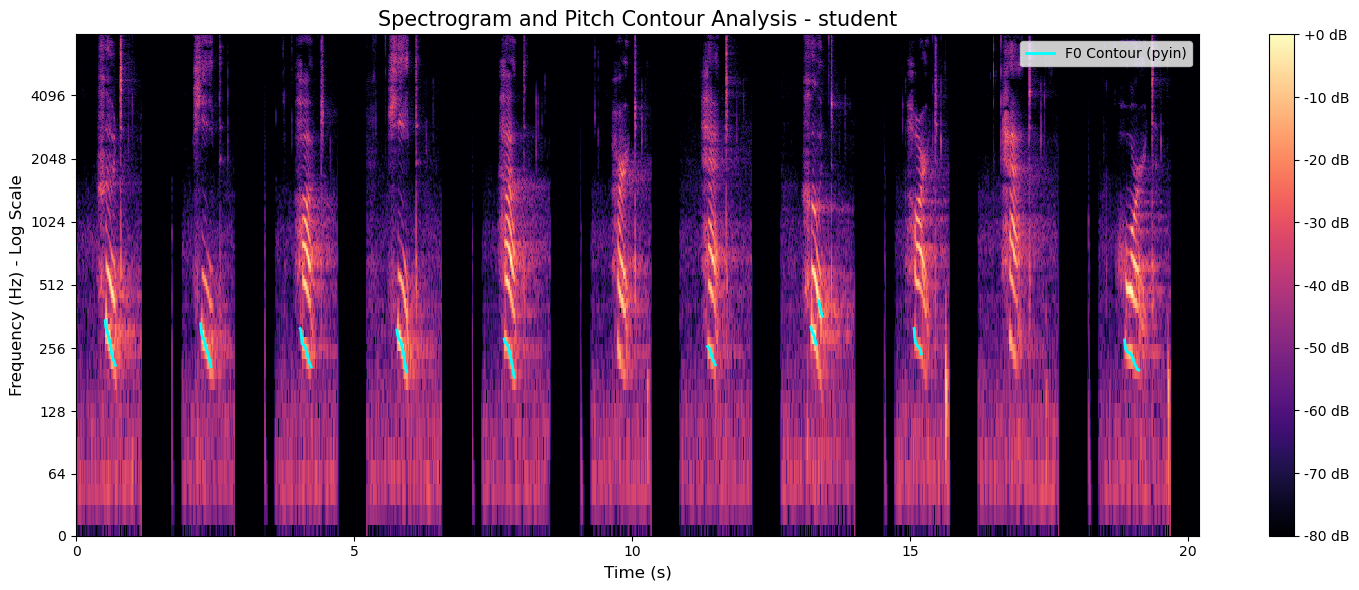

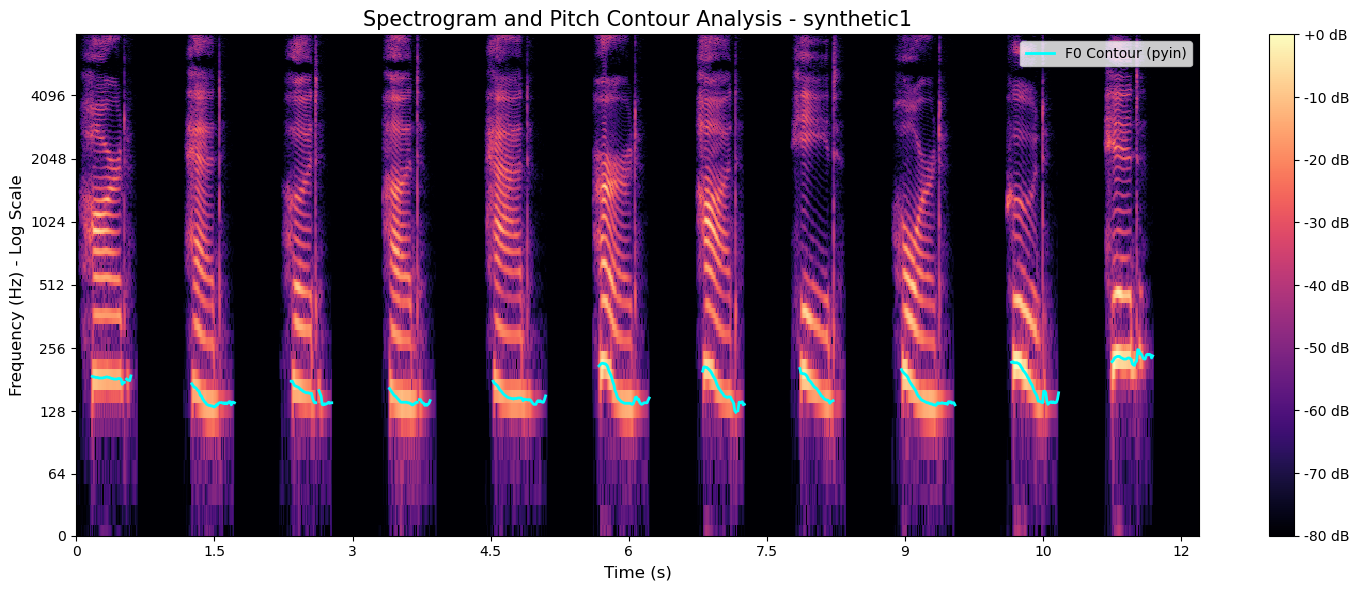

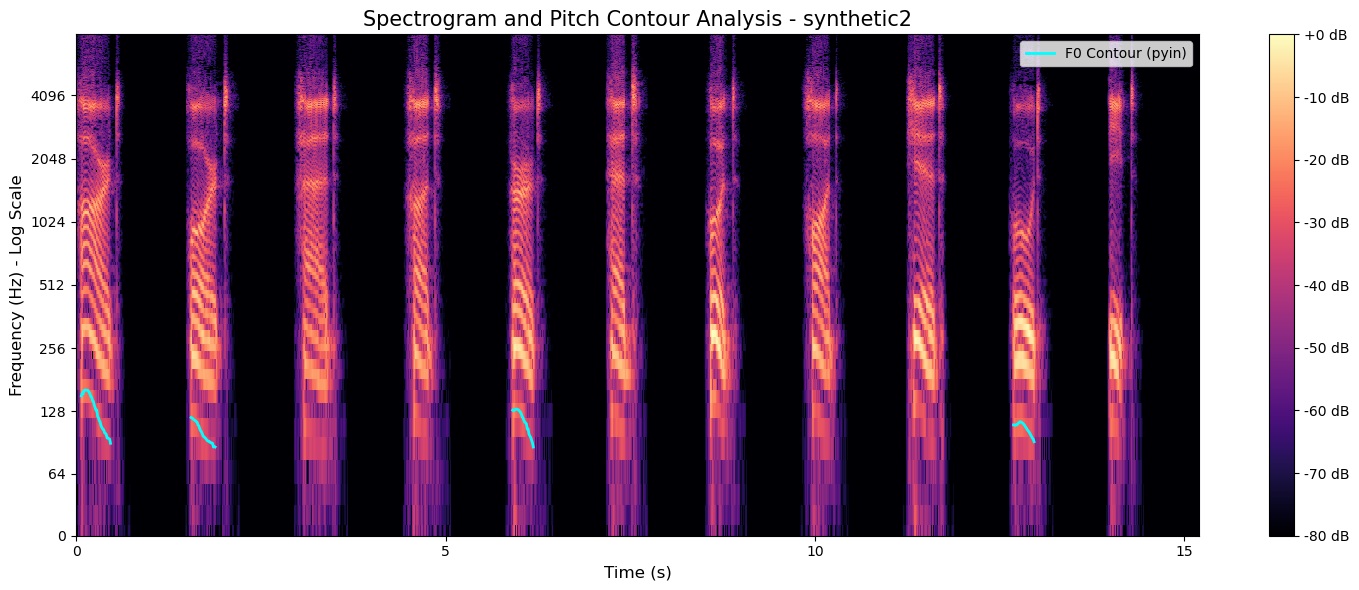

In [23]:
import librosa.display

# Create plots for each speaker
for speaker, data in audio_results.items():
    concat_signal = data['signal']
    sr = data['sr']
    f0 = data['f0']
    times = data['times']
    
    plt.figure(figsize=(15, 6))
    
    # Compute Spectrogram (STFT in dB)
    D = librosa.amplitude_to_db(np.abs(librosa.stft(concat_signal)), ref=np.max)
    
    # Display spectrogram with log scale Y-axis
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log', cmap='magma')
    plt.colorbar(format='%+2.0f dB')
    
    # Overlay the estimated F0 contour
    plt.plot(times, f0, label='F0 Contour (pyin)', color='cyan', linewidth=2, zorder=3)
    
    # Add title and labels
    plt.title(f'Spectrogram and Pitch Contour Analysis - {speaker}', fontsize=15)
    plt.xlabel('Time (s)', fontsize=12)
    plt.ylabel('Frequency (Hz) - Log Scale', fontsize=12)
    plt.ylim([0, 8000]) # Limit view to key speech frequency range
    plt.legend(loc='upper right')
    plt.tight_layout()
    
    plt.show()